# PROJECT OBJECTIVE
Analyze customer transactions and behavior to:

Clean and prepare data
Create useful features
Segment customers
Identify purchase patterns
Detect churn risks
Recommend business improvements

# Import Libraries

In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

pandas → Data processing
numpy → Numerical calculations
matplotlib → Graphs

# Load Dataset

In [6]:
df = pd.read_csv("D://Alfido Tech/CUSTOMER BEHAVIOR ANALYSIS/customer_data.csv")

# Explore Dataset

In [7]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [9]:
df.shape

(250000, 13)

# Summary Statistics

In [10]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [11]:
df.median(numeric_only=True)

Customer ID              25011.0
Product Price              255.0
Quantity                     3.0
Total Purchase Amount     2725.0
Customer Age                44.0
Returns                      1.0
Age                         44.0
Churn                        0.0
dtype: float64

In [12]:
df.mode()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,48382.0,2020-01-01 15:49:02,Electronics,290.0,4.0,2533.0,Credit Card,47.0,1.0,Michael Johnson,47.0,Male,0.0
1,NaN,2020-01-06 22:26:24,NaN,NaN,NaN,4456.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2020-01-07 03:22:08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2020-01-12 02:11:29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,2020-01-12 10:42:25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,NaN,2023-08-17 20:13:45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
268,NaN,2023-08-21 18:09:49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
269,NaN,2023-09-05 03:22:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270,NaN,2023-09-05 09:42:43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

# Data Cleaning

In [14]:
df=df.dropna()

In [15]:
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

# FEATURE ENGINEERING

In [20]:
df["Purchase_Level"]=pd.cut(
    df["Total Purchase Amount"],
    bins=[0,500,1500,5000],
    labels=[
        "Low",
        "Medium",
        "High"
        ]
    )

In [21]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Purchase_Level
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0,High
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0,High
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0,High
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0,Medium
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0,High


# CUSTOMER SEGMENTATION

In [22]:
segment=df.groupby(
    "Customer ID"
    ).agg({"Total Purchase Amount":"sum"
           }
         )
#Create segment
segment["Customer_Type"]=pd.qcut(
    segment["Total Purchase Amount"],
    q=3,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value"
        ]
    )

In [23]:
segment.head()

,Total Purchase Amount,Customer_Type
Customer ID,,
1,5148,Low Value
2,16481,High Value
3,4687,Low Value
4,7826,Low Value
5,7681,Low Value


# Customer Segments visualization

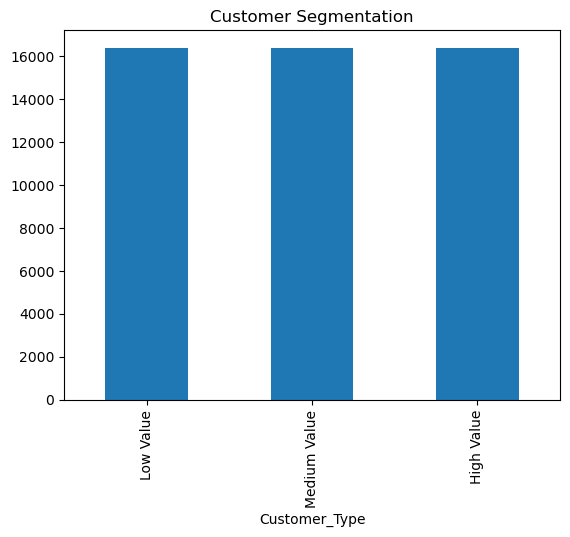

In [24]:
segment[ "Customer_Type" ].value_counts().plot( kind="bar" ) 
plt.title( "Customer Segmentation" ) 
plt.show()

In [ ]:
Shows customer groups.

# Product Purchase Pattern

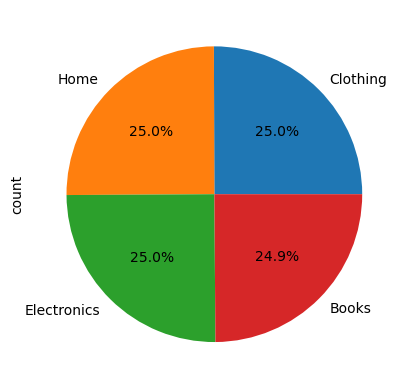

In [25]:
df[ "Product Category" ].value_counts().plot( kind="pie", autopct="%1.1f%%" ) 
plt.show()

# Retention / Churn Trend

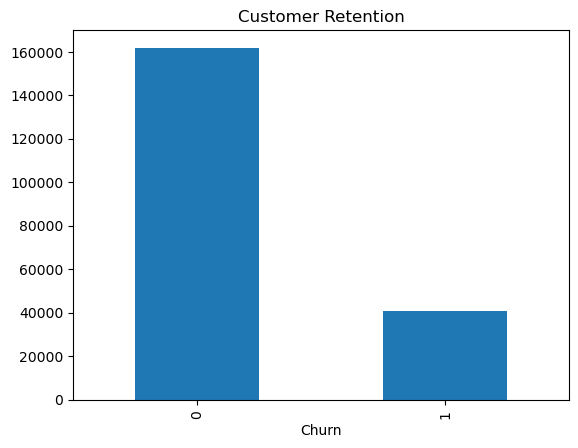

In [26]:
df[ "Churn" ].value_counts().plot( kind="bar" ) 
plt.title( "Customer Retention" ) 
plt.show()

# FINDINGS

# 5 ACTIONABLE RECOMMENDATIONS FOR ALFIDO TECH

# EXECUTIVE SUMMARY